# Notebook A —  Random Forest baseline and tuning

## Cell 1 — Step 0: Configuration

In [1]:
# Step 0 — Two-Phase Experiment Configuration (small ↔ full)

from pathlib import Path
import json
import datetime as dt
import random
import warnings
import time
import math
import shutil
import joblib

from dataclasses import dataclass
from typing import Union, Tuple, Dict, Sequence, Optional, List, Any

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import optuna

warnings.filterwarnings("ignore", category=UserWarning)

# ---- Phase switch ----
PHASE = "small"   # "small" or "full"

# ---- Shared defaults ----
seed = 42
num_classes = 3
label_values = [0, 1, 2]
nodata_value = -9999
ignore_index = -9999

in_channels = 6
bands = ["R", "G", "B", "NIR", "SWIR1", "SWIR2"]
normalisation = "per_band_mean_std"   # computed on TRAIN patches only

CONFIGS = {
    "small": {
        "img_path": "../../data/inputs/map/map_test.tif",
        "lbl_path": "../../data/inputs/label/label_test.tif",

        "patch_size": 256,
        "stride_train": 256,
        "block_size": 2048,

        "split_dir": "../../data/outputs/proposed/small_rf_p256_b2048",

        # RF table extraction budget
        "max_train_pixels_total": 120000,
        "max_val_pixels_total": 40000,
        "max_test_pixels_total": 40000,

        # per-patch cap to avoid a few patches dominating
        "max_pixels_per_patch": 2048,

        # optuna
        "n_trials": 30,
    },
    "full": {
        "img_path": "../../data/inputs/map/map.tif",
        "lbl_path": "../../data/inputs/label/para_three_class.tif",

        "patch_size": 256,
        "stride_train": 256,
        "block_size": 2048,

        "split_dir": "../../data/outputs/proposed/full_rf_p256_b2048",

        "max_train_pixels_total": 300000,
        "max_val_pixels_total": 80000,
        "max_test_pixels_total": 80000,

        "max_pixels_per_patch": 2048,

        "n_trials": 40,
    },
}

assert PHASE in CONFIGS, f"PHASE must be one of {list(CONFIGS.keys())}"

cfg = CONFIGS[PHASE].copy()
cfg.update({
    "phase": PHASE,
    "seed": seed,
    "num_classes": num_classes,
    "label_values": label_values,
    "nodata_value": nodata_value,
    "ignore_index": ignore_index,
    "in_channels": in_channels,
    "bands": bands,
    "normalisation": normalisation,
    "timestamp_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "feature_names_base": bands,
    "feature_names_indices": ["NDVI", "NDWI", "NDBI", "BRIGHTNESS"],
})

split_dir = Path(cfg["split_dir"])
split_dir.mkdir(parents=True, exist_ok=True)

config_path = split_dir / "config_rf_notebook_a.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(cfg, f, indent=2, sort_keys=True)

print("=== Active phase configuration ===")
for k in [
    "phase", "img_path", "lbl_path", "patch_size", "stride_train",
    "block_size", "split_dir", "max_train_pixels_total",
    "max_val_pixels_total", "max_test_pixels_total", "max_pixels_per_patch",
    "n_trials"
]:
    print(f"{k:24s}: {cfg[k]}")
print("saved config:", config_path)

=== Active phase configuration ===
phase                   : small
img_path                : ../../data/inputs/map/map_test.tif
lbl_path                : ../../data/inputs/label/label_test.tif
patch_size              : 256
stride_train            : 256
block_size              : 2048
split_dir               : ../../data/outputs/proposed/small_rf_p256_b2048
max_train_pixels_total  : 120000
max_val_pixels_total    : 40000
max_test_pixels_total   : 40000
max_pixels_per_patch    : 2048
n_trials                : 30
saved config: ../../data/outputs/proposed/small_rf_p256_b2048/config_rf_notebook_a.json


## Cell 2 — Step 1.1: PatchSpec and patch grid

In [2]:
# Step 1.1 — PatchSpec + patch grid

@dataclass(frozen=True)
class PatchSpec:
    row_off: int
    col_off: int
    height: int
    width: int

def build_patch_index(
    img_path: Union[str, Path],
    lbl_path: Union[str, Path],
    patch_size: int,
    stride: int,
) -> List[PatchSpec]:
    img_path = Path(img_path)
    lbl_path = Path(lbl_path)

    with rasterio.open(img_path) as img, rasterio.open(lbl_path) as lbl:
        assert img.width == lbl.width and img.height == lbl.height, "Shape mismatch"
        assert img.transform == lbl.transform, "Transform mismatch"
        assert img.crs == lbl.crs, "CRS mismatch"

        H, W = img.height, img.width
        patches: List[PatchSpec] = []

        for row_off in range(0, H - patch_size + 1, stride):
            for col_off in range(0, W - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))

        if (H - patch_size) % stride != 0:
            row_off = H - patch_size
            for col_off in range(0, W - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))

        if (W - patch_size) % stride != 0:
            col_off = W - patch_size
            for row_off in range(0, H - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))

        if (H - patch_size) % stride != 0 and (W - patch_size) % stride != 0:
            patches.append(PatchSpec(H - patch_size, W - patch_size, patch_size, patch_size))

    return patches

print("PatchSpec ready.")

PatchSpec ready.


## Cell 3 — Step 1.2–1.7: split utilities

In [3]:
# Step 1.2–1.7 — Spatial block split, filtering, mean/std, export/load, integrity checks

def assign_block_id(p: PatchSpec, block_size: int) -> Tuple[int, int]:
    return (p.row_off // block_size, p.col_off // block_size)

def spatial_block_split(
    patches: Sequence[PatchSpec],
    block_size: int,
    ratios=(0.70, 0.15, 0.15),
    seed: int = 42,
):
    assert abs(sum(ratios) - 1.0) < 1e-6, "ratios must sum to 1"

    block_to_patches: Dict[Tuple[int, int], list] = {}
    for p in patches:
        bid = assign_block_id(p, block_size)
        block_to_patches.setdefault(bid, []).append(p)

    block_ids = list(block_to_patches.keys())
    rng = random.Random(seed)
    rng.shuffle(block_ids)

    n = len(block_ids)
    n_train = int(ratios[0] * n)
    n_val = int(ratios[1] * n)

    train_blocks = set(block_ids[:n_train])
    val_blocks = set(block_ids[n_train:n_train + n_val])
    test_blocks = set(block_ids[n_train + n_val:])

    train = [p for bid in train_blocks for p in block_to_patches[bid]]
    val = [p for bid in val_blocks for p in block_to_patches[bid]]
    test = [p for bid in test_blocks for p in block_to_patches[bid]]

    return train, val, test, train_blocks, val_blocks, test_blocks

def has_any_valid_label(lbl_path: Union[str, Path], p: PatchSpec, ignore_index: int) -> bool:
    with rasterio.open(lbl_path) as lbl:
        w = Window(p.col_off, p.row_off, p.width, p.height)
        y = lbl.read(1, window=w)
    return np.any(y != ignore_index)

def filter_all_ignore_patches(lbl_path: Union[str, Path], patch_list: Sequence[PatchSpec], ignore_index: int):
    return [p for p in patch_list if has_any_valid_label(lbl_path, p, ignore_index=ignore_index)]

def estimate_mean_std(
    img_path: Union[str, Path],
    patch_list: Sequence[PatchSpec],
    nodata_value: int,
    max_patches: int = 400,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    n = min(max_patches, len(patch_list))
    sample = rng.choice(np.array(patch_list, dtype=object), size=n, replace=False)

    sums = None
    sumsqs = None
    counts = None

    with rasterio.open(img_path) as img:
        for p in sample:
            w = Window(p.col_off, p.row_off, p.width, p.height)
            x = img.read(window=w).astype(np.float32)

            valid = x != nodata_value

            if sums is None:
                C = x.shape[0]
                sums = np.zeros(C, dtype=np.float64)
                sumsqs = np.zeros(C, dtype=np.float64)
                counts = np.zeros(C, dtype=np.int64)

            for c in range(x.shape[0]):
                vals = x[c][valid[c]]
                counts[c] += vals.size
                if vals.size > 0:
                    sums[c] += vals.sum(dtype=np.float64)
                    sumsqs[c] += (vals.astype(np.float64) ** 2).sum(dtype=np.float64)

    mean = sums / np.maximum(counts, 1)
    var = (sumsqs / np.maximum(counts, 1)) - mean**2
    std = np.sqrt(np.maximum(var, 1e-12))

    return mean.astype(np.float32), std.astype(np.float32)

def export_patch_specs(patches: Sequence[PatchSpec], csv_path: Path) -> pd.DataFrame:
    df = pd.DataFrame([{
        "row_off": p.row_off,
        "col_off": p.col_off,
        "height": p.height,
        "width": p.width,
    } for p in patches])
    df.to_csv(csv_path, index=False)
    return df

def load_patch_specs(csv_path: Path) -> List[PatchSpec]:
    df = pd.read_csv(csv_path)
    return [
        PatchSpec(int(r.row_off), int(r.col_off), int(r.height), int(r.width))
        for r in df.itertuples(index=False)
    ]

def build_export_or_load_splits(
    img_path: Union[str, Path],
    lbl_path: Union[str, Path],
    split_dir: Path,
    patch_size: int,
    stride_train: int,
    block_size: int,
    ratios=(0.70, 0.15, 0.15),
    seed: int = 42,
    nodata_value: int = -9999,
    ignore_index: int = -9999,
):
    split_dir.mkdir(parents=True, exist_ok=True)

    train_csv = split_dir / "train_patches.csv"
    val_csv = split_dir / "val_patches.csv"
    test_csv = split_dir / "test_patches.csv"
    mean_npy = split_dir / "train_mean.npy"
    std_npy = split_dir / "train_std.npy"

    if train_csv.exists() and val_csv.exists() and test_csv.exists() and mean_npy.exists() and std_npy.exists():
        train_patches = load_patch_specs(train_csv)
        val_patches = load_patch_specs(val_csv)
        test_patches = load_patch_specs(test_csv)
        train_mean = np.load(mean_npy)
        train_std = np.load(std_npy)
        meta = {"mode": "loaded_existing"}
        return train_patches, val_patches, test_patches, train_mean, train_std, meta

    patches = build_patch_index(img_path, lbl_path, patch_size=patch_size, stride=stride_train)

    train_patches, val_patches, test_patches, train_blocks, val_blocks, test_blocks = spatial_block_split(
        patches, block_size=block_size, ratios=ratios, seed=seed
    )

    train_patches = filter_all_ignore_patches(lbl_path, train_patches, ignore_index)
    val_patches = filter_all_ignore_patches(lbl_path, val_patches, ignore_index)
    test_patches = filter_all_ignore_patches(lbl_path, test_patches, ignore_index)

    export_patch_specs(train_patches, train_csv)
    export_patch_specs(val_patches, val_csv)
    export_patch_specs(test_patches, test_csv)

    pd.DataFrame(sorted(list(train_blocks)), columns=["block_row", "block_col"]).to_csv(split_dir / "train_blocks.csv", index=False)
    pd.DataFrame(sorted(list(val_blocks)), columns=["block_row", "block_col"]).to_csv(split_dir / "val_blocks.csv", index=False)
    pd.DataFrame(sorted(list(test_blocks)), columns=["block_row", "block_col"]).to_csv(split_dir / "test_blocks.csv", index=False)

    train_mean, train_std = estimate_mean_std(
        img_path=img_path,
        patch_list=train_patches,
        nodata_value=nodata_value,
        max_patches=400,
        seed=seed,
    )
    np.save(mean_npy, train_mean)
    np.save(std_npy, train_std)

    meta = {
        "mode": "built_and_exported",
        "n_patches_total": len(patches),
        "n_train_blocks": len(train_blocks),
        "n_val_blocks": len(val_blocks),
        "n_test_blocks": len(test_blocks),
    }
    return train_patches, val_patches, test_patches, train_mean, train_std, meta

def keys_from_patches(patches: Sequence[PatchSpec]):
    return set((p.row_off, p.col_off, p.height, p.width) for p in patches)

def integrity_check_no_duplicates(train_patches, val_patches, test_patches):
    kt = keys_from_patches(train_patches)
    kv = keys_from_patches(val_patches)
    ks = keys_from_patches(test_patches)

    inter_tv = len(kt & kv)
    inter_ts = len(kt & ks)
    inter_vs = len(kv & ks)

    print("Duplicate patch keys across splits (should all be 0):")
    print("Train ∩ Val :", inter_tv)
    print("Train ∩ Test:", inter_ts)
    print("Val ∩ Test  :", inter_vs)

    assert inter_tv == 0 and inter_ts == 0 and inter_vs == 0, "Overlap detected across splits!"

print("Split utilities ready.")

Split utilities ready.


## Cell 4 — Step 1.8: build/load splits

In [4]:
# Step 1.8 — Run split construction / loading

img_path = cfg["img_path"]
lbl_path = cfg["lbl_path"]
patch_size = int(cfg["patch_size"])
stride_train = int(cfg["stride_train"])
block_size = int(cfg["block_size"])
ratios = (0.70, 0.15, 0.15)

train_patches, val_patches, test_patches, train_mean, train_std, meta = build_export_or_load_splits(
    img_path=img_path,
    lbl_path=lbl_path,
    split_dir=split_dir,
    patch_size=patch_size,
    stride_train=stride_train,
    block_size=block_size,
    ratios=ratios,
    seed=cfg["seed"],
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
)

print("\n=== Split build/load ===")
print("Mode:", meta.get("mode"))
print("Train/Val/Test:", len(train_patches), len(val_patches), len(test_patches))
if "n_patches_total" in meta:
    print("Total patches (pre-filter):", meta["n_patches_total"])
    print("Blocks (train/val/test):", meta["n_train_blocks"], meta["n_val_blocks"], meta["n_test_blocks"])

integrity_check_no_duplicates(train_patches, val_patches, test_patches)

print("\nSaved artefacts in:", split_dir)
print(" - train/val/test CSVs")
print(" - train_mean.npy, train_std.npy")
print(" - train/val/test blocks CSVs")


=== Split build/load ===
Mode: built_and_exported
Train/Val/Test: 2012 432 520
Total patches (pre-filter): 2964
Blocks (train/val/test): 34 7 8
Duplicate patch keys across splits (should all be 0):
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Saved artefacts in: ../../data/outputs/proposed/small_rf_p256_b2048
 - train/val/test CSVs
 - train_mean.npy, train_std.npy
 - train/val/test blocks CSVs


## Cell 5 — Step 2.1: feature helpers

In [5]:
# Step 2.1 — Feature engineering helpers

def safe_divide(a, b, eps=1e-6):
    return a / np.where(np.abs(b) < eps, eps, b)

def compute_feature_stack(x_chw: np.ndarray) -> Tuple[np.ndarray, List[str]]:
    """
    Input:
      x_chw: [C,H,W] with 6 bands in order [R,G,B,NIR,SWIR1,SWIR2]
    Returns:
      feats: [F,H,W]
      names: feature names
    """
    R, G, B, NIR, SWIR1, SWIR2 = [x_chw[i].astype(np.float32) for i in range(6)]

    NDVI = safe_divide(NIR - R, NIR + R)
    NDWI = safe_divide(G - NIR, G + NIR)
    NDBI = safe_divide(SWIR1 - NIR, SWIR1 + NIR)
    BRIGHTNESS = (R + G + B + NIR + SWIR1 + SWIR2) / 6.0

    feats = np.stack(
        [R, G, B, NIR, SWIR1, SWIR2, NDVI, NDWI, NDBI, BRIGHTNESS],
        axis=0
    )

    names = bands + ["NDVI", "NDWI", "NDBI", "BRIGHTNESS"]
    return feats.astype(np.float32), names

def normalise_image_patch(x_chw: np.ndarray, mean: np.ndarray, std: np.ndarray, nodata_value: int) -> np.ndarray:
    valid = (x_chw != nodata_value)
    mean = mean.reshape(-1, 1, 1)
    std = std.reshape(-1, 1, 1)
    x_norm = (x_chw - mean) / std
    x_out = np.where(valid, x_norm, 0.0).astype(np.float32)
    return x_out

print("Feature helpers ready.")

Feature helpers ready.


## Cell 6 — Step 2.2: patch reading + pixel table extraction

In [8]:
# Step 2.2 — Read a patch and extract sampled pixel rows for RF

def read_patch(img_path: str, lbl_path: str, p: PatchSpec):
    w = Window(p.col_off, p.row_off, p.width, p.height)
    with rasterio.open(img_path) as img, rasterio.open(lbl_path) as lbl:
        x = img.read(window=w).astype(np.float32)   # [C,H,W]
        y = lbl.read(1, window=w).astype(np.int64)  # [H,W]
    return x, y

def extract_pixel_rows_from_patch(
    img_path: str,
    lbl_path: str,
    p: PatchSpec,
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
    max_pixels_per_patch: int,
    rng: np.random.Generator,
):
    x_raw, y = read_patch(img_path, lbl_path, p)
    x = normalise_image_patch(x_raw, train_mean, train_std, nodata_value)
    feat_stack, feat_names = compute_feature_stack(x)   # [F,H,W]

    valid_label = (y != ignore_index)

    band_valid = np.all(x_raw != nodata_value, axis=0)
    valid = valid_label & band_valid

    rr, cc = np.where(valid)
    n_valid = len(rr)

    if n_valid == 0:
        return None, None, feat_names

    n_take = min(max_pixels_per_patch, n_valid)
    choose = rng.choice(n_valid, size=n_take, replace=False)

    rr = rr[choose]
    cc = cc[choose]

    X = feat_stack[:, rr, cc].T.astype(np.float32)   # [N,F]
    y_vec = y[rr, cc].astype(np.int64)

    return X, y_vec, feat_names

def build_rf_table_from_patches(
    split_name: str,
    img_path: str,
    lbl_path: str,
    patches: Sequence[PatchSpec],
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
    max_pixels_total: int,
    max_pixels_per_patch: int,
    seed: int,
):
    rng = np.random.default_rng(seed)
    patch_order = np.arange(len(patches))
    rng.shuffle(patch_order)

    rows_X = []
    rows_y = []
    rows_meta = []
    feat_names_final = None

    total = 0
    for idx in patch_order:
        p = patches[int(idx)]

        Xp, yp, feat_names = extract_pixel_rows_from_patch(
            img_path=img_path,
            lbl_path=lbl_path,
            p=p,
            train_mean=train_mean,
            train_std=train_std,
            nodata_value=nodata_value,
            ignore_index=ignore_index,
            max_pixels_per_patch=max_pixels_per_patch,
            rng=rng,
        )

        if Xp is None:
            continue

        remaining = max_pixels_total - total
        if remaining <= 0:
            break

        if len(yp) > remaining:
            choose = rng.choice(len(yp), size=remaining, replace=False)
            Xp = Xp[choose]
            yp = yp[choose]

        rows_X.append(Xp)
        rows_y.append(yp)

        meta_patch = pd.DataFrame([{
            "split": split_name,
            "patch_idx": int(idx),
            "row_off": int(p.row_off),
            "col_off": int(p.col_off),
            "n_pixels_used": int(len(yp)),
        }])
        rows_meta.append(meta_patch)

        feat_names_final = feat_names
        total += len(yp)

        if total >= max_pixels_total:
            break

    X = np.vstack(rows_X).astype(np.float32) if rows_X else np.empty((0, 0), dtype=np.float32)
    y = np.concatenate(rows_y).astype(np.int64) if rows_y else np.empty((0,), dtype=np.int64)
    meta_df = pd.concat(rows_meta, ignore_index=True) if rows_meta else pd.DataFrame()

    return X, y, meta_df, feat_names_final

print("Patch reading + RF table extraction ready.")

Patch reading + RF table extraction ready.


## Cell 7 — Step 2.3: build train/val/test RF tables

In [9]:
# Step 2.3 — Build sampled RF tables for baseline/tuning

X_train, y_train, meta_train_table, feature_names = build_rf_table_from_patches(
    split_name="train",
    img_path=img_path,
    lbl_path=lbl_path,
    patches=train_patches,
    train_mean=train_mean,
    train_std=train_std,
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
    max_pixels_total=int(cfg["max_train_pixels_total"]),
    max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
    seed=int(cfg["seed"]),
)

X_val, y_val, meta_val_table, _ = build_rf_table_from_patches(
    split_name="val",
    img_path=img_path,
    lbl_path=lbl_path,
    patches=val_patches,
    train_mean=train_mean,
    train_std=train_std,
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
    max_pixels_total=int(cfg["max_val_pixels_total"]),
    max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
    seed=int(cfg["seed"]) + 1,
)

X_test, y_test, meta_test_table, _ = build_rf_table_from_patches(
    split_name="test",
    img_path=img_path,
    lbl_path=lbl_path,
    patches=test_patches,
    train_mean=train_mean,
    train_std=train_std,
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
    max_pixels_total=int(cfg["max_test_pixels_total"]),
    max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
    seed=int(cfg["seed"]) + 2,
)

np.save(split_dir / "X_train_rf.npy", X_train)
np.save(split_dir / "y_train_rf.npy", y_train)
np.save(split_dir / "X_val_rf.npy", X_val)
np.save(split_dir / "y_val_rf.npy", y_val)
np.save(split_dir / "X_test_rf.npy", X_test)
np.save(split_dir / "y_test_rf.npy", y_test)

pd.DataFrame({"feature_name": feature_names}).to_csv(split_dir / "rf_feature_names.csv", index=False)
meta_train_table.to_csv(split_dir / "rf_table_meta_train.csv", index=False)
meta_val_table.to_csv(split_dir / "rf_table_meta_val.csv", index=False)
meta_test_table.to_csv(split_dir / "rf_table_meta_test.csv", index=False)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

print("\nClass counts:")
for split_name, y_arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    vals, cnts = np.unique(y_arr, return_counts=True)
    print(split_name, dict(zip(vals.tolist(), cnts.tolist())))

X_train: (120000, 10) y_train: (120000,)
X_val  : (40000, 10) y_val  : (40000,)
X_test : (40000, 10) y_test : (40000,)

Class counts:
train {0: 92251, 1: 27529, 2: 220}
val {0: 29254, 1: 10265, 2: 481}
test {0: 30725, 1: 9149, 2: 126}


## Cell 8 — Step 3: metrics + quick RF baseline

In [10]:
# Step 3 — Quick RF baseline

def macro_iou_from_arrays(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> float:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
    cm = cm.astype(np.float64)

    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    denom = tp + fp + fn

    iou = np.divide(tp, denom, out=np.full_like(tp, np.nan, dtype=np.float64), where=denom > 0)
    present = cm.sum(axis=1) > 0
    return float(np.nanmean(iou[present]))

def overall_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float((y_true == y_pred).mean())

def fit_and_evaluate_rf(params: dict, X_train, y_train, X_val, y_val, num_classes: int):
    clf = RandomForestClassifier(**params)
    clf.fit(X_train, y_train)

    y_val_pred = clf.predict(X_val)
    y_val_proba = clf.predict_proba(X_val)

    metrics = {
        "val_macro_iou": macro_iou_from_arrays(y_val, y_val_pred, num_classes=num_classes),
        "val_oa": overall_accuracy(y_val, y_val_pred),
        "model": clf,
        "y_val_pred": y_val_pred,
        "y_val_proba": y_val_proba,
    }
    return metrics

RF_BASELINE_PARAMS = {
    "n_estimators": 200,
    "criterion": "gini",
    "max_depth": 25,
    "min_samples_split": 4,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
    "max_samples": 0.7,
    "class_weight": "balanced",
    "n_jobs": -1,
    "random_state": int(cfg["seed"]),
}

t0 = time.time()
baseline_res = fit_and_evaluate_rf(
    RF_BASELINE_PARAMS,
    X_train, y_train,
    X_val, y_val,
    num_classes=cfg["num_classes"]
)
t1 = time.time()

baseline_model = baseline_res["model"]
baseline_val_pred = baseline_res["y_val_pred"]

print("=== Quick RF baseline ===")
print("val_macro_iou :", round(baseline_res["val_macro_iou"], 4))
print("val_oa        :", round(baseline_res["val_oa"], 4))
print("train_time_sec:", round(t1 - t0, 2))

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": baseline_model.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.to_csv(split_dir / "rf_baseline_feature_importance.csv", index=False)
display(feat_imp)

=== Quick RF baseline ===
val_macro_iou : 0.6605
val_oa        : 0.908
train_time_sec: 3.43


,feature,importance
1,G,0.215205
2,B,0.139879
0,R,0.122725
5,SWIR2,0.110073
4,SWIR1,0.101302
8,NDBI,0.096086
9,BRIGHTNESS,0.093194
7,NDWI,0.048219
6,NDVI,0.039550
3,NIR,0.033766


## Cell 9 — Step 4.1: Optuna objective

In [11]:
# Step 4.1 — Optuna objective for RF tuning

def build_rf_from_trial(trial: optuna.trial.Trial, seed: int):
    max_features_choice = trial.suggest_categorical(
        "max_features_mode",
        ["sqrt", "log2", "float"]
    )

    if max_features_choice == "float":
        max_features = trial.suggest_float("max_features_float", 0.3, 1.0)
    else:
        max_features = max_features_choice

    bootstrap = trial.suggest_categorical("bootstrap", [True, False])

    if bootstrap:
        max_samples = trial.suggest_float("max_samples", 0.4, 1.0)
    else:
        max_samples = None

    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        max_depth=trial.suggest_int("max_depth", 10, 40, step=5),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=max_features,
        bootstrap=bootstrap,
        max_samples=max_samples,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=seed,
    )
    return clf

def objective(trial: optuna.trial.Trial):
    clf = build_rf_from_trial(trial, seed=int(cfg["seed"]))
    clf.fit(X_train, y_train)

    y_val_pred = clf.predict(X_val)
    val_macro_iou = macro_iou_from_arrays(y_val, y_val_pred, num_classes=cfg["num_classes"])

    trial.set_user_attr("val_oa", overall_accuracy(y_val, y_val_pred))
    return val_macro_iou

print("Optuna objective ready.")

Optuna objective ready.


## Cell 10 — Step 4.2: run Optuna study

In [12]:
# Step 4.2 — Run Optuna study

study_path = split_dir / "optuna_rf_study.db"
study_name = f"rf_baseline_tuning_{cfg['phase']}"

storage_url = f"sqlite:///{study_path}"

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    study_name=study_name,
    storage=storage_url,
    direction="maximize",
    load_if_exists=True,
)

print("Study name :", study_name)
print("Storage    :", storage_url)
print("Trials before optimize:", len(study.trials))

study.optimize(
    objective,
    n_trials=int(cfg["n_trials"]),
    show_progress_bar=True,
)

print("\n=== Best trial ===")
print("Best value (val_macro_iou):", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Study name : rf_baseline_tuning_small
Storage    : sqlite:///../../data/outputs/proposed/small_rf_p256_b2048/optuna_rf_study.db
Trials before optimize: 0


/usr/local/lib/python3.8/dist-packages/optuna/progress_bar.py:49: ExperimentalWarning: Progress bar is experimental (supported from v1.2.0). The interface can change in the future.
  self._init_valid()


  0%|          | 0/30 [00:00<?, ?it/s]


=== Best trial ===
Best value (val_macro_iou): 0.698364543241535
Best params:
  bootstrap: False
  class_weight: balanced
  criterion: entropy
  max_depth: 30
  max_features_mode: sqrt
  min_samples_leaf: 10
  min_samples_split: 20
  n_estimators: 300


## Cell 11 — Step 4.3: export Optuna results

In [13]:
# Step 4.3 — Export Optuna trial table

trials_df = study.trials_dataframe()
trials_csv = split_dir / "optuna_rf_trials.csv"
trials_df.to_csv(trials_csv, index=False)

best_params_json = split_dir / "rf_best_params_optuna.json"
with open(best_params_json, "w", encoding="utf-8") as f:
    json.dump(study.best_params, f, indent=2)

print("Saved:", trials_csv)
print("Saved:", best_params_json)

display(
    trials_df.sort_values("value", ascending=False).head(10)
)

Saved: ../../data/outputs/proposed/small_rf_p256_b2048/optuna_rf_trials.csv
Saved: ../../data/outputs/proposed/small_rf_p256_b2048/rf_best_params_optuna.json


,number,value,datetime_start,datetime_complete,duration,params_bootstrap,params_class_weight,params_criterion,params_max_depth,params_max_features_float,params_max_features_mode,params_max_samples,params_min_samples_leaf,params_min_samples_split,params_n_estimators,user_attrs_val_oa,state
25,25,0.698365,2026-04-16 07:23:46.849977,2026-04-16 07:24:01.258301,0 days 00:00:14.408324,False,balanced,entropy,30,NaN,sqrt,NaN,10,20,300,0.899525,COMPLETE
10,10,0.697541,2026-04-16 07:20:30.375628,2026-04-16 07:20:42.506164,0 days 00:00:12.130536,False,balanced,entropy,40,NaN,sqrt,NaN,10,20,350,0.899375,COMPLETE
12,12,0.697541,2026-04-16 07:20:54.827768,2026-04-16 07:21:08.287474,0 days 00:00:13.459706,False,balanced,entropy,40,NaN,sqrt,NaN,10,20,350,0.899375,COMPLETE
11,11,0.697541,2026-04-16 07:20:42.699627,2026-04-16 07:20:54.641132,0 days 00:00:11.941505,False,balanced,entropy,40,NaN,sqrt,NaN,10,20,350,0.899375,COMPLETE
21,21,0.697541,2026-04-16 07:22:51.686386,2026-04-16 07:23:04.965814,0 days 00:00:13.279428,False,balanced,entropy,40,NaN,sqrt,NaN,10,20,350,0.899375,COMPLETE
23,23,0.696578,2026-04-16 07:23:19.287105,2026-04-16 07:23:30.344390,0 days 00:00:11.057285,False,balanced,entropy,35,NaN,sqrt,NaN,10,16,250,0.899350,COMPLETE
1,1,0.690536,2026-04-16 07:19:12.643550,2026-04-16 07:19:26.903263,0 days 00:00:14.259713,False,balanced,log_loss,40,NaN,sqrt,NaN,9,16,400,0.900050,COMPLETE
24,24,0.690536,2026-04-16 07:23:30.727305,2026-04-16 07:23:46.318805,0 days 00:00:15.591500,False,balanced,entropy,40,NaN,sqrt,NaN,9,18,400,0.900050,COMPLETE
20,20,0.690536,2026-04-16 07:22:38.579655,2026-04-16 07:22:51.556416,0 days 00:00:12.976761,False,balanced,entropy,40,NaN,sqrt,NaN,9,18,400,0.900050,COMPLETE
27,27,0.689679,2026-04-16 07:24:14.103696,2026-04-16 07:24:25.313641,0 days 00:00:11.209945,False,balanced,entropy,20,NaN,sqrt,NaN,9,18,300,0.900025,COMPLETE


## Cell 12 — Step 5.1: rebuild final tuned RF

In [14]:
# Step 5.1 — Build final tuned RF from best Optuna params

best_params = study.best_params.copy()

max_features_mode = best_params.pop("max_features_mode")
if max_features_mode == "float":
    max_features = best_params.pop("max_features_float")
else:
    max_features = max_features_mode
    best_params.pop("max_features_float", None)

bootstrap = best_params["bootstrap"]
if not bootstrap:
    best_params["max_samples"] = None

RF_TUNED_PARAMS = dict(best_params)
RF_TUNED_PARAMS.update({
    "max_features": max_features,
    "n_jobs": -1,
    "random_state": int(cfg["seed"]),
})

print("=== Final tuned RF params ===")
for k, v in RF_TUNED_PARAMS.items():
    print(f"{k:20s}: {v}")

t0 = time.time()
rf_final = RandomForestClassifier(**RF_TUNED_PARAMS)
rf_final.fit(X_train, y_train)
t1 = time.time()

joblib.dump(rf_final, split_dir / "rf_model_tuned.joblib")
with open(split_dir / "rf_model_tuned_params.json", "w", encoding="utf-8") as f:
    json.dump(RF_TUNED_PARAMS, f, indent=2)

print("\nSaved:", split_dir / "rf_model_tuned.joblib")
print("Saved:", split_dir / "rf_model_tuned_params.json")
print("train_time_sec:", round(t1 - t0, 2))

=== Final tuned RF params ===
bootstrap           : False
class_weight        : balanced
criterion           : entropy
max_depth           : 30
min_samples_leaf    : 10
min_samples_split   : 20
n_estimators        : 300
max_samples         : None
max_features        : sqrt
n_jobs              : -1
random_state        : 42

Saved: ../../data/outputs/proposed/small_rf_p256_b2048/rf_model_tuned.joblib
Saved: ../../data/outputs/proposed/small_rf_p256_b2048/rf_model_tuned_params.json
train_time_sec: 8.95


## Cell 13 — Step 5.2: final tuned evaluation on val + test

In [15]:
# Step 5.2 — Final tuned RF evaluation on val and test

y_val_pred = rf_final.predict(X_val)
y_test_pred = rf_final.predict(X_test)

y_val_proba = rf_final.predict_proba(X_val)
y_test_proba = rf_final.predict_proba(X_test)

eval_summary = {
    "val_macro_iou": macro_iou_from_arrays(y_val, y_val_pred, cfg["num_classes"]),
    "val_oa": overall_accuracy(y_val, y_val_pred),
    "test_macro_iou": macro_iou_from_arrays(y_test, y_test_pred, cfg["num_classes"]),
    "test_oa": overall_accuracy(y_test, y_test_pred),
}

with open(split_dir / "rf_tuned_eval_summary.json", "w", encoding="utf-8") as f:
    json.dump(eval_summary, f, indent=2)

print("=== Final tuned RF evaluation ===")
for k, v in eval_summary.items():
    print(f"{k:18s}: {v:.4f}")

print("\nValidation classification report:")
print(classification_report(y_val, y_val_pred, labels=label_values, digits=4))

print("\nTest classification report:")
print(classification_report(y_test, y_test_pred, labels=label_values, digits=4))

=== Final tuned RF evaluation ===
val_macro_iou     : 0.6984
val_oa            : 0.8995
test_macro_iou    : 0.4086
test_oa           : 0.7615

Validation classification report:
              precision    recall  f1-score   support

           0     0.9517    0.9124    0.9316     29254
           1     0.7755    0.8775    0.8234     10265
           2     0.8338    0.5842    0.6870       481

    accuracy                         0.8995     40000
   macro avg     0.8537    0.7914    0.8140     40000
weighted avg     0.9050    0.8995    0.9009     40000


Test classification report:
              precision    recall  f1-score   support

           0     0.9460    0.7349    0.8272     30725
           1     0.5154    0.8559    0.6434      9149
           2     0.0502    0.3730    0.0885       126

    accuracy                         0.7615     40000
   macro avg     0.5039    0.6546    0.5197     40000
weighted avg     0.8447    0.7615    0.7828     40000



## Cell 14 — Step 5.3: final tuned feature importance

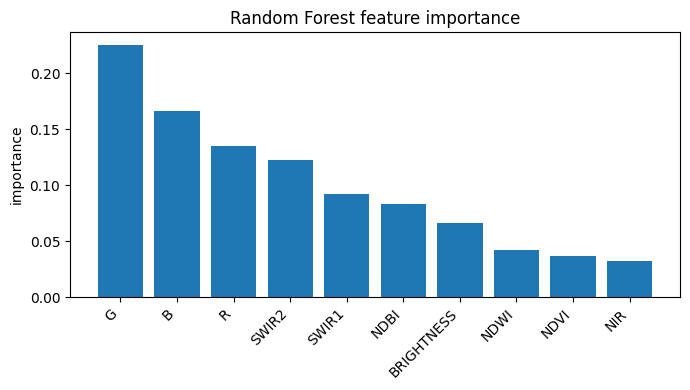

,feature,importance
1,G,0.225155
2,B,0.166435
0,R,0.134470
5,SWIR2,0.122276
4,SWIR1,0.091885
8,NDBI,0.082818
9,BRIGHTNESS,0.065955
7,NDWI,0.042049
6,NDVI,0.036322
3,NIR,0.032635


In [16]:
# Step 5.3 — Final tuned RF feature importance

feat_imp_final = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp_final.to_csv(split_dir / "rf_tuned_feature_importance.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(feat_imp_final["feature"], feat_imp_final["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Random Forest feature importance")
plt.ylabel("importance")
plt.tight_layout()
plt.show()

display(feat_imp_final)

## Cell 15 — Step 6.1: patch-level probability scoring helpers

In [17]:
# Step 6.1 — Patch-level RF scoring helpers

def entropy_from_proba(p: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    p = np.clip(p, eps, 1.0)
    return -(p * np.log(p)).sum(axis=1)

def rf_predict_patch_maps(
    model: RandomForestClassifier,
    img_path: str,
    lbl_path: str,
    p: PatchSpec,
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
):
    x_raw, y = read_patch(img_path, lbl_path, p)
    x = normalise_image_patch(x_raw, train_mean, train_std, nodata_value)
    feat_stack, feat_names = compute_feature_stack(x)

    H, W = y.shape
    F = feat_stack.shape[0]

    band_valid = np.all(x_raw != nodata_value, axis=0)
    valid = (y != ignore_index) & band_valid

    pred_map = np.full((H, W), fill_value=ignore_index, dtype=np.int64)
    conf_map = np.full((H, W), fill_value=np.nan, dtype=np.float32)
    entropy_map = np.full((H, W), fill_value=np.nan, dtype=np.float32)

    if valid.sum() == 0:
        return {
            "pred_map": pred_map,
            "conf_map": conf_map,
            "entropy_map": entropy_map,
            "label_map": y,
            "valid_mask": valid,
            "feat_names": feat_names,
            "x_norm": x,
        }

    X_valid = feat_stack[:, valid].T.reshape(-1, F).astype(np.float32)
    proba = model.predict_proba(X_valid)
    pred = model.predict(X_valid)
    conf = proba.max(axis=1)
    ent = entropy_from_proba(proba)

    pred_map[valid] = pred
    conf_map[valid] = conf.astype(np.float32)
    entropy_map[valid] = ent.astype(np.float32)

    return {
        "pred_map": pred_map,
        "conf_map": conf_map,
        "entropy_map": entropy_map,
        "label_map": y,
        "valid_mask": valid,
        "feat_names": feat_names,
        "x_norm": x,
    }

print("Patch scoring helpers ready.")

Patch scoring helpers ready.


## Cell 16 — Step 6.2: score one patch visually

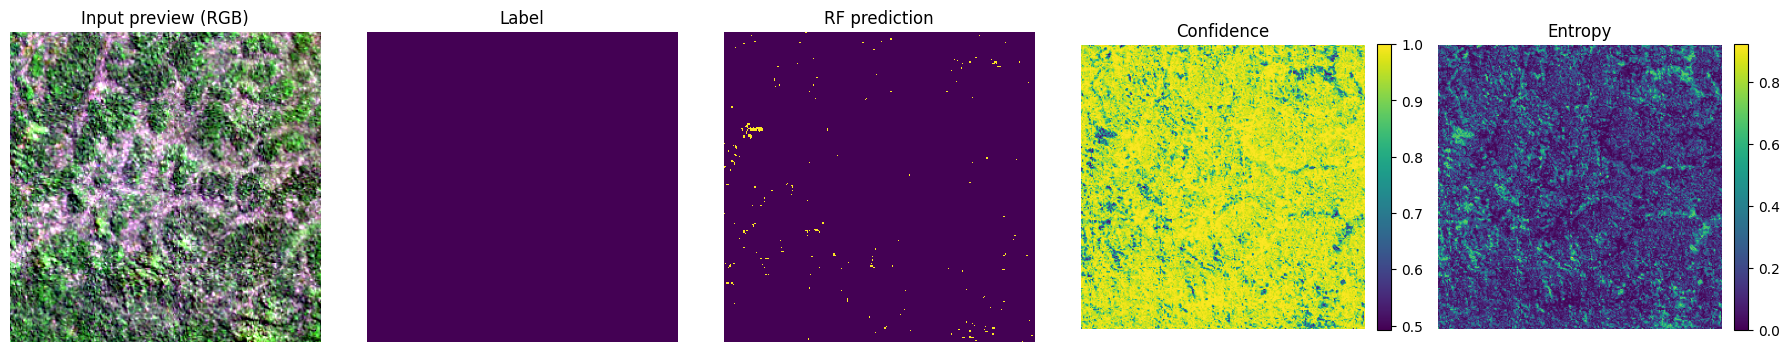

In [18]:
# Step 6.2 — Visualise one patch

def tensor_to_rgb_np(x_chw: np.ndarray, rgb_idx=(0, 1, 2), stretch=True):
    rgb = x_chw[list(rgb_idx), :, :].transpose(1, 2, 0).astype(np.float32)

    if stretch:
        out = np.zeros_like(rgb)
        for c in range(3):
            lo, hi = np.percentile(rgb[..., c], [2, 98])
            out[..., c] = (rgb[..., c] - lo) / (hi - lo + 1e-12)
        rgb = np.clip(out, 0, 1)
    else:
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-12)
    return rgb

example_idx = 0
p = val_patches[example_idx]

maps = rf_predict_patch_maps(
    model=rf_final,
    img_path=img_path,
    lbl_path=lbl_path,
    p=p,
    train_mean=train_mean,
    train_std=train_std,
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
)

rgb = tensor_to_rgb_np(maps["x_norm"], rgb_idx=(0, 1, 2), stretch=True)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(rgb)
axes[0].set_title("Input preview (RGB)")
axes[0].axis("off")

axes[1].imshow(maps["label_map"], interpolation="nearest")
axes[1].set_title("Label")
axes[1].axis("off")

axes[2].imshow(maps["pred_map"], interpolation="nearest")
axes[2].set_title("RF prediction")
axes[2].axis("off")

im3 = axes[3].imshow(maps["conf_map"])
axes[3].set_title("Confidence")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

im4 = axes[4].imshow(maps["entropy_map"])
axes[4].set_title("Entropy")
axes[4].axis("off")
plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Cell 17 — Step 6.3: score all patches in a split

In [19]:
# Step 6.3 — Score all patches in train / val / test

def score_patch_rf(
    model: RandomForestClassifier,
    img_path: str,
    lbl_path: str,
    p: PatchSpec,
    idx: int,
    split_name: str,
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
):
    maps = rf_predict_patch_maps(
        model=model,
        img_path=img_path,
        lbl_path=lbl_path,
        p=p,
        train_mean=train_mean,
        train_std=train_std,
        nodata_value=nodata_value,
        ignore_index=ignore_index,
    )

    valid = maps["valid_mask"]
    if valid.sum() == 0:
        return None

    y = maps["label_map"][valid]
    pred = maps["pred_map"][valid]
    conf = maps["conf_map"][valid]
    ent = maps["entropy_map"][valid]

    accuracy = float((pred == y).mean())
    disagree_frac = float((pred != y).mean())

    return {
        "split": split_name,
        "idx": int(idx),
        "row_off": int(p.row_off),
        "col_off": int(p.col_off),
        "entropy_mean": float(np.nanmean(ent)),
        "entropy_p95": float(np.nanquantile(ent, 0.95)),
        "conf_mean": float(np.nanmean(conf)),
        "accuracy": float(accuracy),
        "disagree_frac": float(disagree_frac),
    }

def score_patch_list_rf(
    split_name: str,
    patch_list: Sequence[PatchSpec],
    model: RandomForestClassifier,
    img_path: str,
    lbl_path: str,
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
):
    rows = []
    for i, p in enumerate(patch_list):
        row = score_patch_rf(
            model=model,
            img_path=img_path,
            lbl_path=lbl_path,
            p=p,
            idx=i,
            split_name=split_name,
            train_mean=train_mean,
            train_std=train_std,
            nodata_value=nodata_value,
            ignore_index=ignore_index,
        )
        if row is not None:
            rows.append(row)
    return pd.DataFrame(rows)

df_train_scores = score_patch_list_rf(
    "train", train_patches, rf_final, img_path, lbl_path,
    train_mean, train_std, cfg["nodata_value"], cfg["ignore_index"]
)
df_val_scores = score_patch_list_rf(
    "val", val_patches, rf_final, img_path, lbl_path,
    train_mean, train_std, cfg["nodata_value"], cfg["ignore_index"]
)
df_test_scores = score_patch_list_rf(
    "test", test_patches, rf_final, img_path, lbl_path,
    train_mean, train_std, cfg["nodata_value"], cfg["ignore_index"]
)

print(df_train_scores.shape, df_val_scores.shape, df_test_scores.shape)

(2012, 9) (432, 9) (520, 9)


## Cell 18 — Step 6.4: export patch scores

In [20]:
# Step 6.4 — Export patch score tables

train_scores_path = split_dir / "train_patch_scores_rf.csv"
val_scores_path = split_dir / "val_patch_scores_rf.csv"
test_scores_path = split_dir / "test_patch_scores_rf.csv"
all_scores_path = split_dir / "patch_scores_all_rf.csv"

df_train_scores.to_csv(train_scores_path, index=False)
df_val_scores.to_csv(val_scores_path, index=False)
df_test_scores.to_csv(test_scores_path, index=False)

df_all_scores = pd.concat([df_train_scores, df_val_scores, df_test_scores], ignore_index=True)
df_all_scores.to_csv(all_scores_path, index=False)

top_uncertain = df_all_scores.sort_values("entropy_mean", ascending=False).head(25)
top_uncertain.to_csv(split_dir / "top_uncertain_entropy_rf.csv", index=False)

print("Saved:", train_scores_path)
print("Saved:", val_scores_path)
print("Saved:", test_scores_path)
print("Saved:", all_scores_path)
print("Saved:", split_dir / "top_uncertain_entropy_rf.csv")

display(df_all_scores.head())

Saved: ../../data/outputs/proposed/small_rf_p256_b2048/train_patch_scores_rf.csv
Saved: ../../data/outputs/proposed/small_rf_p256_b2048/val_patch_scores_rf.csv
Saved: ../../data/outputs/proposed/small_rf_p256_b2048/test_patch_scores_rf.csv
Saved: ../../data/outputs/proposed/small_rf_p256_b2048/patch_scores_all_rf.csv
Saved: ../../data/outputs/proposed/small_rf_p256_b2048/top_uncertain_entropy_rf.csv


,split,idx,row_off,col_off,entropy_mean,entropy_p95,conf_mean,accuracy,disagree_frac
0,train,0,8192,0,0.259579,0.690145,0.899674,0.882568,0.117432
1,train,1,8192,256,0.240114,0.687405,0.910227,0.887955,0.112045
2,train,2,8192,512,0.246825,0.689696,0.903081,0.888687,0.111313
3,train,3,8192,768,0.267870,0.689527,0.894966,0.889923,0.110077
4,train,4,8192,1024,0.319701,0.685959,0.877847,0.877823,0.122177


## Cell 19 — Step 6.5: quick patch-score diagnostics

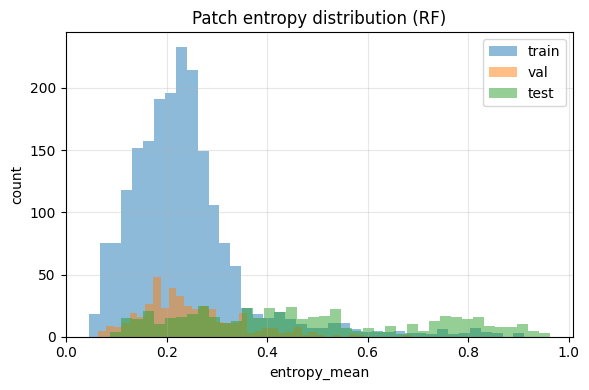

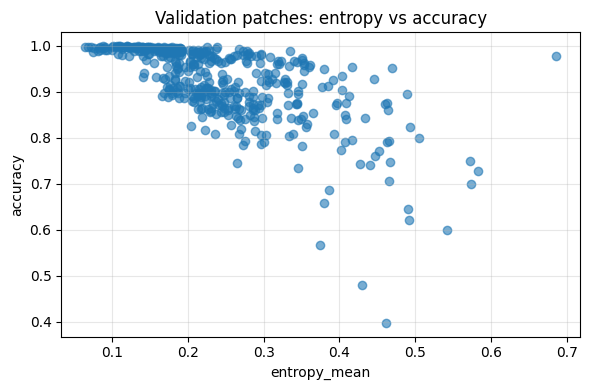

Correlation (val entropy_mean vs accuracy): -0.6524385168974249


In [21]:
# Step 6.5 — Patch-score diagnostics

plt.figure(figsize=(6, 4))
for split_name, d in [("train", df_train_scores), ("val", df_val_scores), ("test", df_test_scores)]:
    plt.hist(d["entropy_mean"].dropna(), bins=40, alpha=0.5, label=split_name)
plt.title("Patch entropy distribution (RF)")
plt.xlabel("entropy_mean")
plt.ylabel("count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df_val_scores["entropy_mean"], df_val_scores["accuracy"], alpha=0.6)
plt.title("Validation patches: entropy vs accuracy")
plt.xlabel("entropy_mean")
plt.ylabel("accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlation (val entropy_mean vs accuracy):", df_val_scores["entropy_mean"].corr(df_val_scores["accuracy"]))